In [2]:
import numpy as np  
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset , DataLoader

from nn_live import Visualizer

import os

from sklearn.model_selection import train_test_split


In [3]:
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "pip", "install", "-e",
#     r"C:\Users\ankit\Desktop\pytorch\DL_Visulization_tool"])


In [4]:
if torch.cuda.is_available():
    print(torch.cuda.get_device_name())
else:
    print("CPU")

NVIDIA GeForce RTX 4050 Laptop GPU


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ankit\.cache\kagglehub\datasets\zalando-research\fashionmnist\versions\4


In [6]:
os.listdir(path)

['fashion-mnist_test.csv',
 'fashion-mnist_train.csv',
 't10k-images-idx3-ubyte',
 't10k-labels-idx1-ubyte',
 'train-images-idx3-ubyte',
 'train-labels-idx1-ubyte']

In [7]:
path_train=os.path.join(path, "fashion-mnist_train.csv")
path_test=os.path.join(path, "fashion-mnist_test.csv")

In [8]:
# set random Seeds dor reproducibility
torch.manual_seed(42)

In [9]:
df=pd.read_csv(path_train)
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


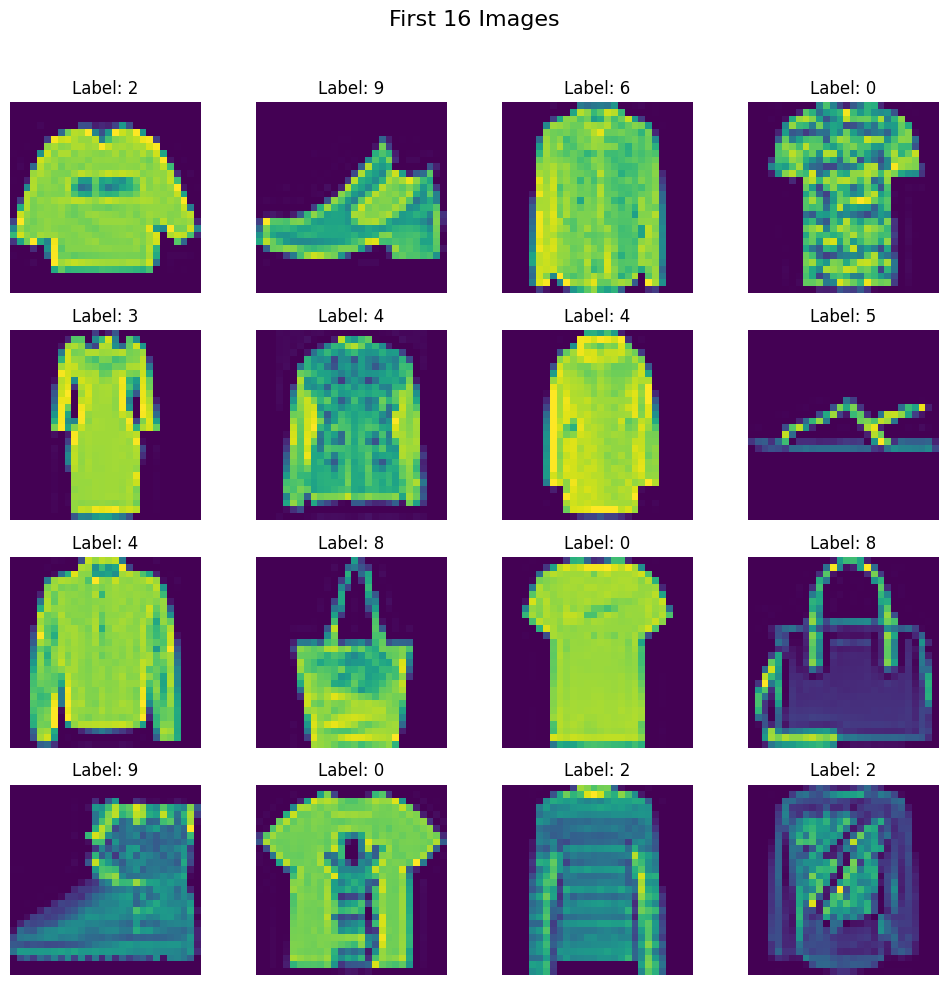

In [10]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [11]:
X = df.drop('label',axis=1)
y= df['label']

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

- Why divide by 255?<br>
    - Images store pixel intensity from 0–255 (uint8)<br>
    - Neural networks work better with small, normalized values<br>
    - Prevents unstable gradients and slow learning

In [13]:

 # scaling the feautures
X_train = X_train/255.0
X_test = X_test/255.0

In [14]:
# create CustomDataset Class
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    self.features = torch.tensor(features.to_numpy(), dtype=torch.float32)
    self.labels = torch.tensor(labels.to_numpy(), dtype=torch.long)

  def __len__(self):

    return len(self.features)

  def __getitem__(self, index):

    return self.features[index], self.labels[index]



In [15]:
train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test,y_test)


In [16]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)


In [ ]:
class ANN(nn.Module):
    def __init__(self,num_features):

        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64,10),

        )

    def forward(self,features):
        out = self.network(features)

        return(out)

In [18]:
learning_rate = 0.1
epoch = 25

In [19]:
model = ANN(X_train.shape[1])
model = model.to(device='cuda')

In [20]:
# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [21]:
len(train_loader)

1500

In [22]:
viz = Visualizer(model, port=8000)

for epoch in range(epoch):

    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:

        # move data to gpu
        batch_features = batch_features.to(device='cuda')
        batch_labels = batch_labels.to(device='cuda')

        # forward pass
        outputs = model(batch_features)

        # calculate loss
        loss = criterion(outputs, batch_labels)

        # back pass
        optimizer.zero_grad()
        loss.backward()

        # update grads
        optimizer.step()

        total_epoch_loss = total_epoch_loss + loss.item()

        viz.step(epoch=epoch+1, loss=loss)
        
    avg_loss = total_epoch_loss/len(train_loader)
    print(f'Epoch: {epoch + 1}, Loss: {avg_loss}',flush=True)


c:\Users\ankit\Desktop\pytorch\DL_Visulization_tool\nn_live\__init__.py:42: UserWarning: nn_live: Input layer has 784 neurons. The browser will ask you whether to render all neurons or cap the display for performance.
  self.tracker   = ModelTracker(model)
c:\Users\ankit\Desktop\pytorch\DL_Visulization_tool\nn_live\__init__.py:42: UserWarning: nn_live: Layer 'network.0' has 128 neurons. The browser will ask you whether to render all neurons or cap the display for performance.
  self.tracker   = ModelTracker(model)
c:\Users\ankit\Desktop\pytorch\DL_Visulization_tool\nn_live\__init__.py:42: UserWarning: nn_live: Layer 'network.3' has 64 neurons. The browser will ask you whether to render all neurons or cap the display for performance.
  self.tracker   = ModelTracker(model)


nn_live: Live Visualizer started at http://127.0.0.1:8000
  [PERF WARNING] Input layer has 784 neurons. The browser will ask you whether to render all neurons or cap the display for performance.
  [PERF WARNING] Layer 'network.0' has 128 neurons. The browser will ask you whether to render all neurons or cap the display for performance.
  [PERF WARNING] Layer 'network.3' has 64 neurons. The browser will ask you whether to render all neurons or cap the display for performance.
Epoch: 1, Loss: 2.1055379564762116
Epoch: 2, Loss: 1.8684793604214986
Epoch: 3, Loss: 1.7795107746124268
Epoch: 4, Loss: 1.7382860657374064
Epoch: 5, Loss: 1.7097343824704487
Epoch: 6, Loss: 1.6893185763359069
Epoch: 7, Loss: 1.676850910027822
Epoch: 8, Loss: 1.6523370037873586
Epoch: 9, Loss: 1.6490602056980133
Epoch: 10, Loss: 1.635656701564789
Epoch: 11, Loss: 1.6295885181427001
Epoch: 12, Loss: 1.6230556399822236
Epoch: 13, Loss: 1.6115557169914245
Epoch: 14, Loss: 1.5992438536485036
Epoch: 15, Loss: 1.59907042

In [23]:
model.eval()


ANN(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.9, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Dropout(p=0.9, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [24]:
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

        # move data to gpu
    batch_features = batch_features.to(device='cuda')
    batch_labels = batch_labels.to(device='cuda')

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.5923333333333334


In [25]:
len(test_loader)

375

In [26]:
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

        # move data to gpu
    batch_features = batch_features.to(device='cuda')
    batch_labels = batch_labels.to(device='cuda')

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.5968333333333333


# Hyperparameter Tunning

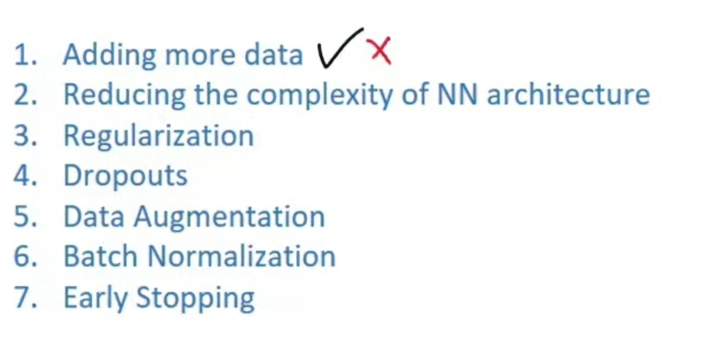

# Dropout

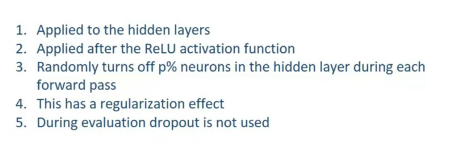

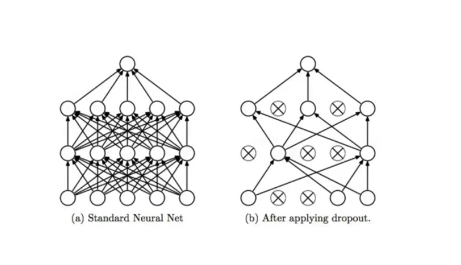

# Batch Normalization

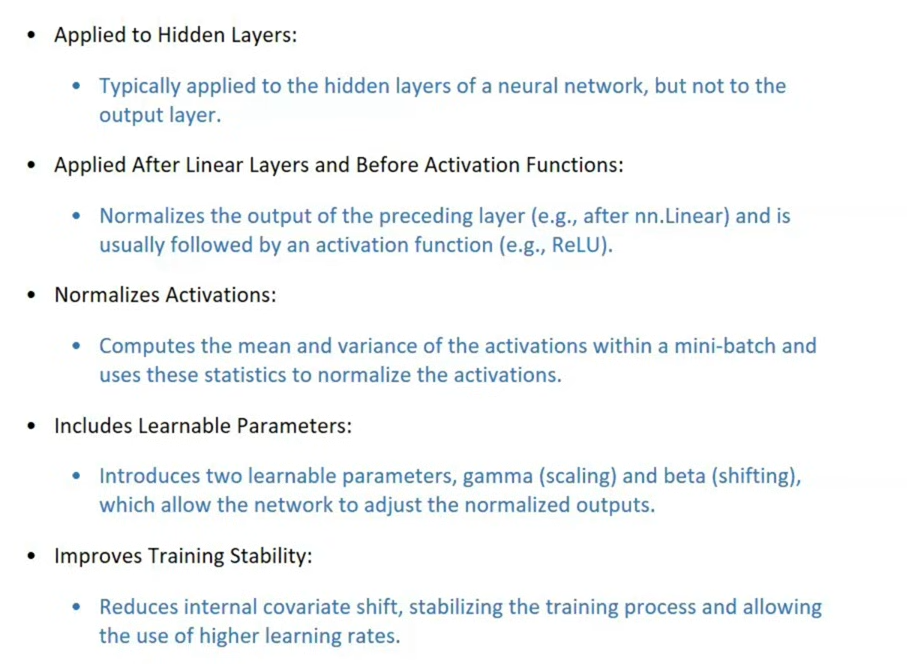

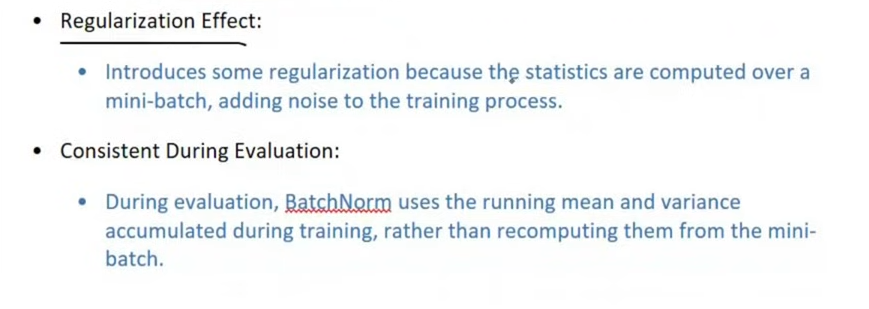

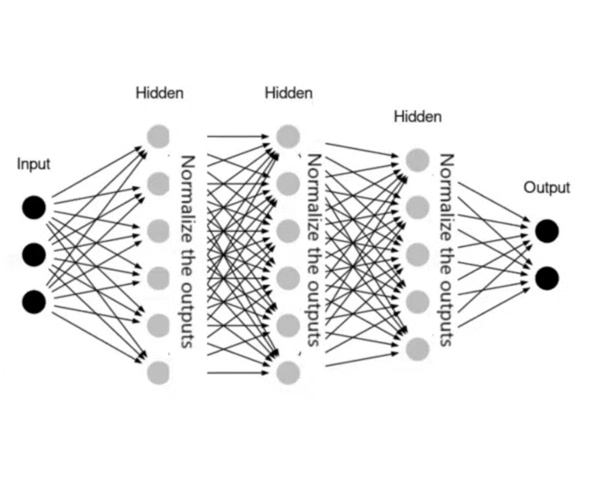

# Regularization

L1 Regularization <br>
L2 Regularization

L1 (Lasso) and L2 (Ridge) regularization are techniques to prevent machine learning model overfitting by adding a penalty term to the cost function, reducing model complexity and variance. L1 adds the sum of absolute weight values (forcing sparse, zero weights for feature selection), while L2 adds the sum of squared weights (shrinking weights evenly).

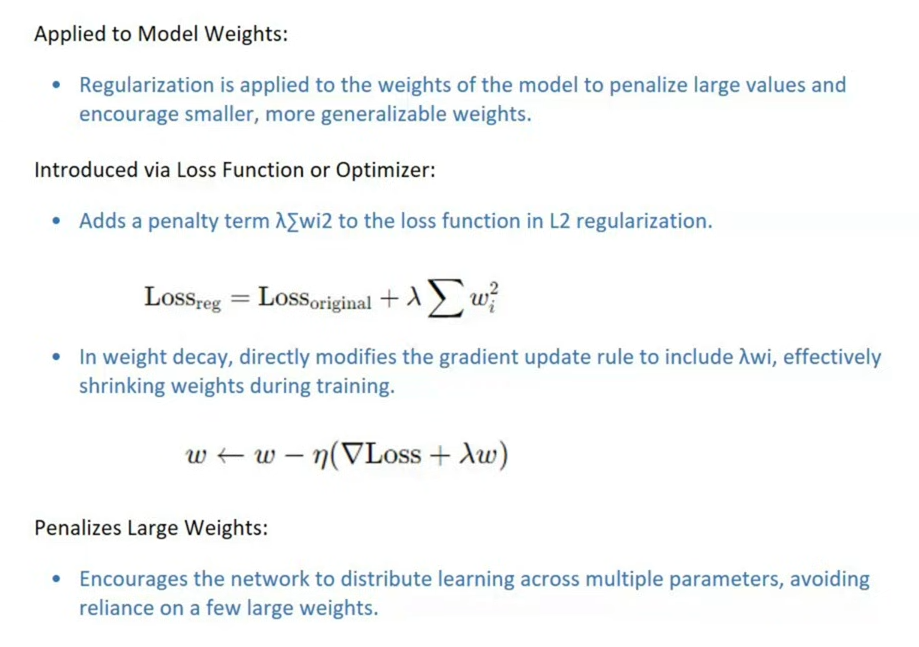